In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("crop_predict.csv")
print(df.head())

           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           2051.4    75755.32     246.76     0.238333  
3           2051.4  1870661.52    6093.36  5238.051739  
4           2051.4   165500.63     539.09     0.420909  


In [3]:
print(df.isnull().sum())

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64


In [4]:
cat_columns = ["Crop", "Season", "State"]

In [5]:
for col in cat_columns:
    df[col] = df[col].astype(str).str.strip()

In [6]:
df = pd.get_dummies(df, columns=cat_columns)

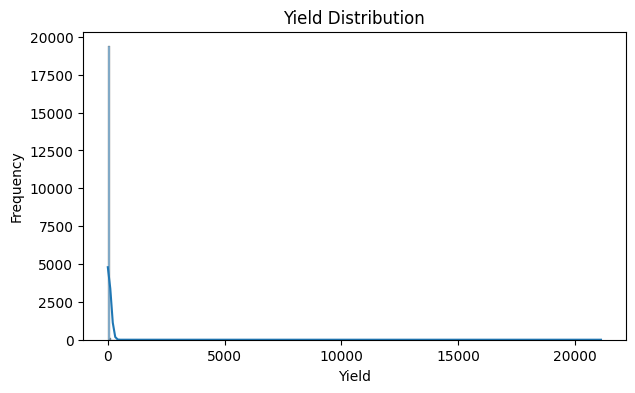

In [7]:
plt.figure(figsize=(7,4))
sns.histplot(df['Yield'], kde=True)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

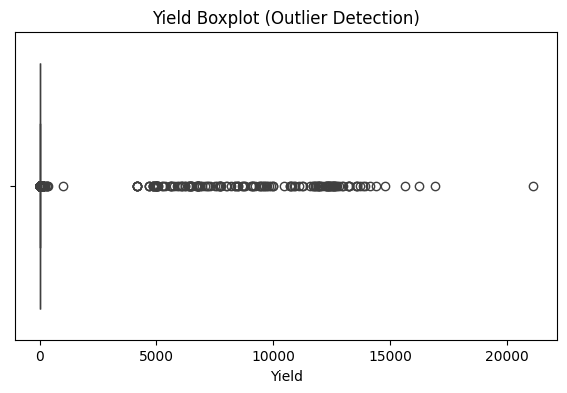

In [8]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df['Yield'])
plt.title("Yield Boxplot (Outlier Detection)")
plt.show()

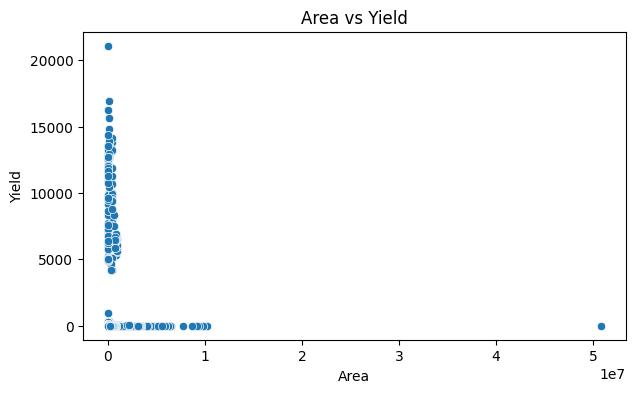

In [9]:
plt.figure(figsize=(7,4))
sns.scatterplot(x=df['Area'], y=df['Yield'])
plt.title("Area vs Yield")
plt.show()


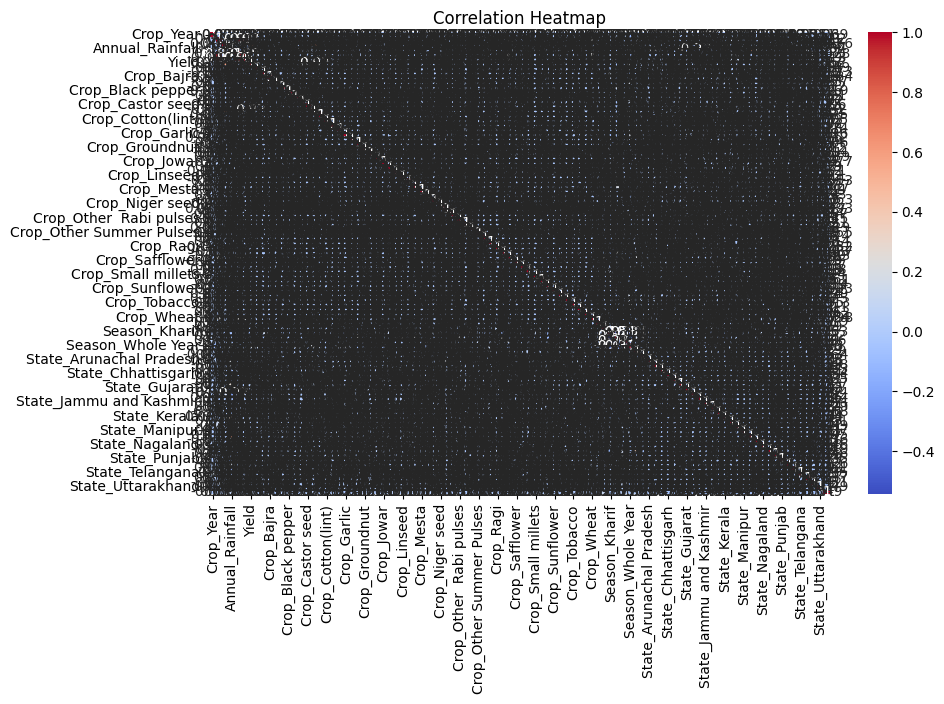

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [11]:
X = df.drop("Yield", axis=1)
y = df["Yield"]

In [12]:
feature_train, feature_test, target_train, target_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = DecisionTreeRegressor(random_state=42)

In [14]:
model.fit(feature_train, target_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [15]:
y_pred = model.predict(feature_test)

In [16]:
print("MSE:", mean_squared_error(target_test, y_pred))
print("R2 Score:", r2_score(target_test, y_pred))

MSE: 18616.782728063998
R2 Score: 0.9767650318669585
